In [ ]:
from scripts.utils.utils import *
from scripts.preprocessing.preprocessing import *
from scripts.preprocessing.data_loader import ThermalDataset

from skimage.feature import hog
import numpy as np
import os 
from dotenv import load_dotenv
from pathlib import Path

In [ ]:
load_dotenv()
ROOT_DIR = Path(os.getenv("ROOT_DIR"))

data_path = ROOT_DIR / "data"

In [ ]:
images_dir = os.path.join(data_path, "images_merged")
masks_dir = os.path.join(data_path, "mask_merged")
print("Images directory: ", images_dir, " Masks directory: ", masks_dir)

dataset = ThermalDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    height=256, 
    width=384,
)
print("Number of images: ", len(dataset))

Images directory:  ../BCXTT/data/images  Masks directory:  ../BCXTT/data/mask_merged
Number of images:  244


In [23]:
import random
id_image = random.randint(0, 200)
print("Random image ID: ", id_image)
id_image = 3

image, mask = dataset[id_image]
image = image.numpy()
mask = mask.numpy()
print("Image shape: ", image.shape)

Random image ID:  46
Image shape:  (1, 256, 384)


In [24]:
print(f"Min value of the original image: {image.min()}")
print(f"Max value of the original image: {image.max()}")
print(f"Shape of the original image: {image.shape}")

Min value of the original image: 0.0
Max value of the original image: 1.0
Shape of the original image: (1, 256, 384)


## Cropping

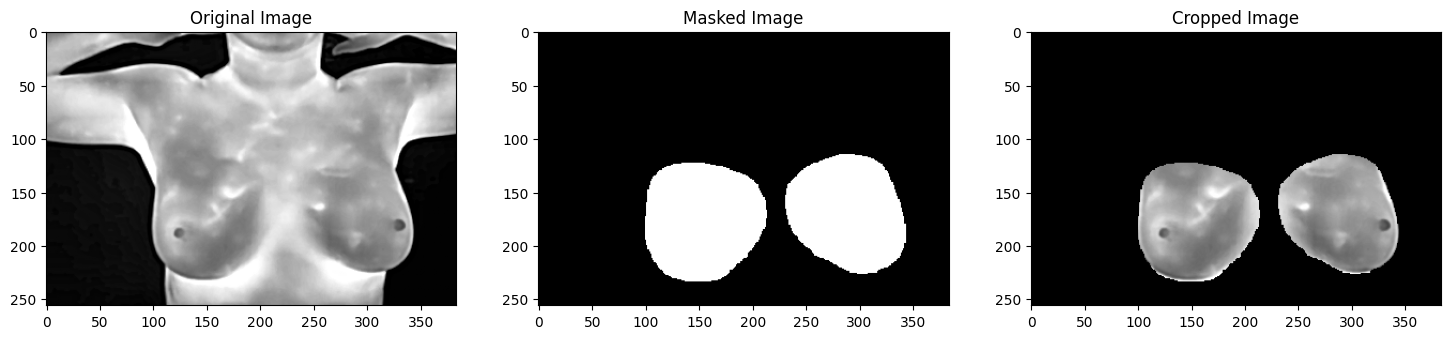

In [ ]:
image = image[0]
image = preprocess_raw_image(image)
cropped = image * mask
cropped = cropped.astype(np.float32)

fig, ax = plt.subplots(1, 3, figsize=(18, 8))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Original Image")
ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Masked Image")
ax[2].imshow(cropped, cmap="gray")
ax[2].set_title("Cropped Image")
plt.show()

In [26]:
cropped_images, cropped_masks = crop_breasts(image, mask)
print(f"Number of cropped images: {len(cropped_images)}, Number of cropped masks: {len(cropped_masks)}")

Number of cropped images: 2, Number of cropped masks: 2


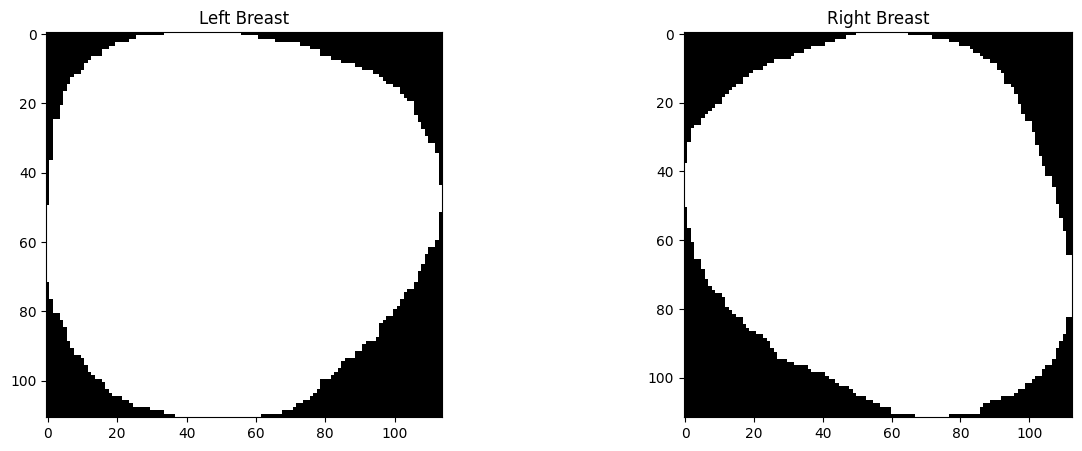

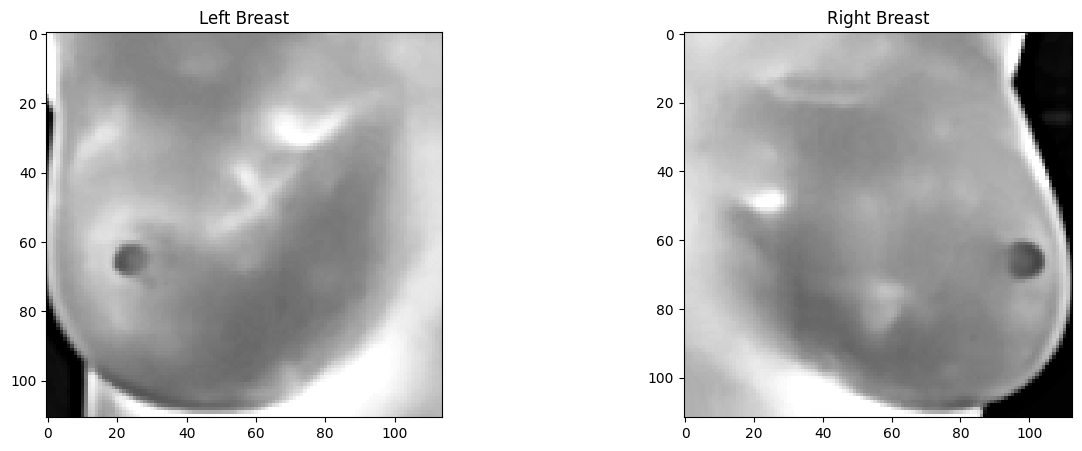

In [27]:
left = cropped_images[0]
right = cropped_images[1]
left_mask = cropped_masks[0]
right_mask = cropped_masks[1]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(left_mask, cmap="gray")
ax[0].set_title("Left Breast")
ax[1].imshow(right_mask, cmap="gray")
ax[1].set_title("Right Breast")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(left, cmap="gray")
ax[0].set_title("Left Breast")
ax[1].imshow(right, cmap="gray")
ax[1].set_title("Right Breast")
plt.show()

In [28]:
patch_size = 100
left = reshape_array(left, patch_size, patch_size)[0]
left_mask = reshape_array(left_mask, patch_size, patch_size)[0]
left = np.flip(left, axis=1)
left_mask = np.flip(left_mask, axis=1)
#left = left*left_mask


right = reshape_array(right, patch_size, patch_size)[0]
right_mask = reshape_array(right_mask, patch_size, patch_size)[0]
print(left.shape)
print(right.shape)

(100, 100)
(100, 100)


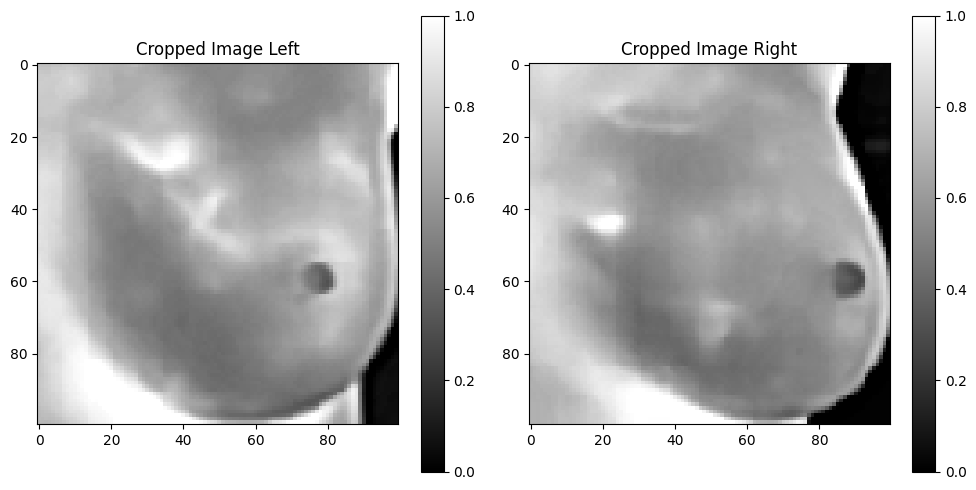

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(left, cmap="gray")
ax[0].set_title("Cropped Image Left")
ax[1].imshow(right, cmap="gray")
ax[1].set_title("Cropped Image Right")
plt.colorbar(ax[0].imshow(left, cmap="gray"), ax=ax[0])
plt.colorbar(ax[1].imshow(right, cmap="gray"), ax=ax[1])
plt.tight_layout()
plt.show()

## Image Registration

In [30]:
print(right.shape, left.shape, right.dtype, left.dtype, right.min(), right.max(), left.min(), left.max())
left = left.astype(np.float32) * 255
right = right.astype(np.float32) * 255
left = left.astype(np.uint8)
right = right.astype(np.uint8)
print(right.shape, left.shape, right.dtype, left.dtype, right.min(), right.max(), left.min(), left.max())

(100, 100) (100, 100) float32 float32 0.0 1.0 0.0 1.0
(100, 100) (100, 100) uint8 uint8 0 255 0 255


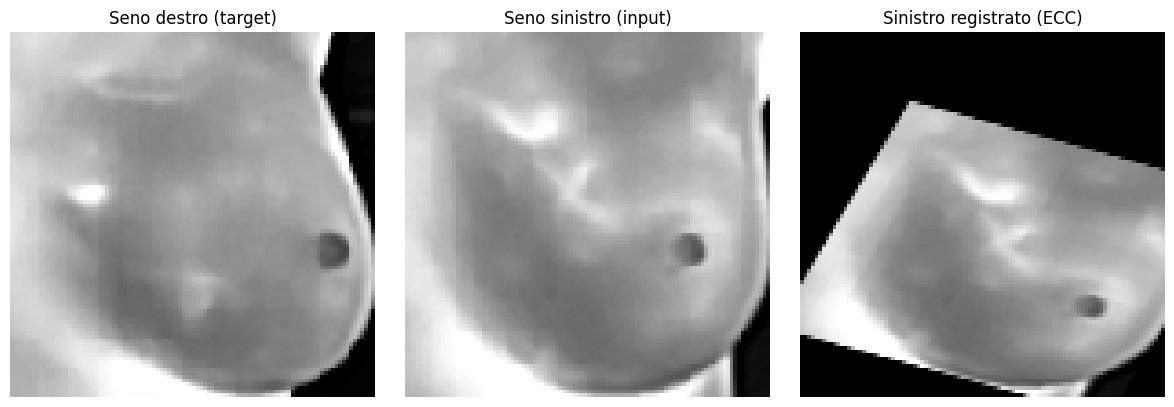

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

assert right.shape == left.shape, "Images must have the same size"

im1 = right.astype(np.float32)
im2 = left.astype(np.float32)
if im1.max() > 1.0:
    im1 /= 255.0
if im2.max() > 1.0:
    im2 /= 255.0

warp_mode = cv2.MOTION_AFFINE 
number_of_iterations = 5000
termination_eps = 1e-6
criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, number_of_iterations, termination_eps)

warp_matrix = np.eye(2, 3, dtype=np.float32)

(cc, warp_matrix) = cv2.findTransformECC(im1, im2, warp_matrix, warp_mode, criteria)

rows, cols = right.shape
im2_aligned = cv2.warpAffine(left, warp_matrix, (cols, rows), flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(right, cmap='gray')
plt.title('Seno destro (target)')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(left, cmap='gray')
plt.title('Seno sinistro (input)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(im2_aligned, cmap='gray')
plt.title('Sinistro registrato (ECC)')
plt.axis('off')
plt.tight_layout()
plt.show()


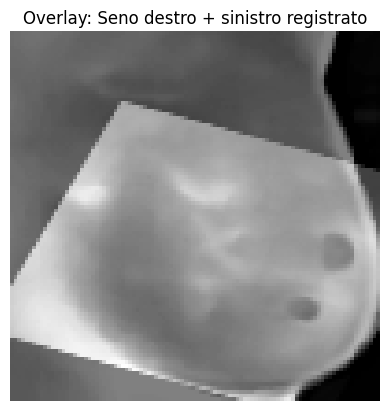

In [ ]:
alpha = 0.5 
blended1 = cv2.addWeighted(right, alpha, im2_aligned, 1 - alpha, 0)

plt.imshow(blended1, cmap='gray')
plt.title('Overlay: Right breast + registered left breast')
plt.axis('off')
plt.show()


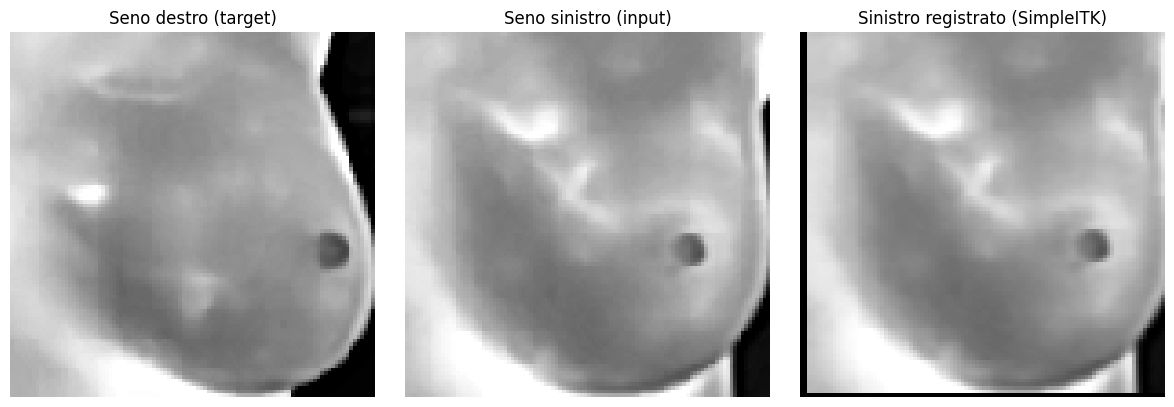

In [ ]:
import SimpleITK as sitk

fixed = sitk.GetImageFromArray(right.astype(np.float32))
moving = sitk.GetImageFromArray(left.astype(np.float32))

registration_method = sitk.ImageRegistrationMethod()
registration_method.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
registration_method.SetInterpolator(sitk.sitkLinear)

registration_method.SetOptimizerAsRegularStepGradientDescent(
    learningRate=1.0,
    minStep=1e-6,
    numberOfIterations=300,
    gradientMagnitudeTolerance=1e-8
)

transform = sitk.TranslationTransform(fixed.GetDimension())
registration_method.SetInitialTransform(transform)
final_transform = registration_method.Execute(fixed, moving)
resampled = sitk.Resample(
    moving, fixed, final_transform,
    sitk.sitkLinear, 0.0, moving.GetPixelID()
)

registered = sitk.GetArrayFromImage(resampled)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(right, cmap='gray')
plt.title("Right breast (target)")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(left, cmap='gray')
plt.title("Left breast (input)")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(registered, cmap='gray')
plt.title("Left breast (registered, SimpleITK)")
plt.axis('off')
plt.tight_layout()
plt.show()


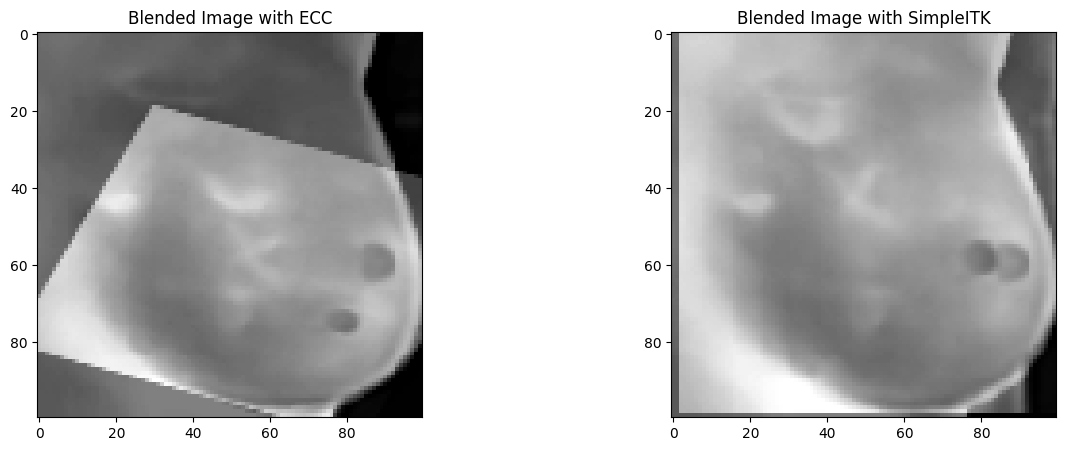

In [ ]:
alpha = 0.5  
registered = registered.astype("uint8")
blended2 = cv2.addWeighted(right, alpha, registered, 1 - alpha, 0)

plt.figure(figsize=(6, 6))
plt.imshow(blended2, cmap="gray")
plt.title('Overlay: Right breast + registered left breast (SimpleITK)')
plt.axis('off')
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(blended1, cmap="gray")
ax[0].set_title("Blended Image with ECC")
ax[1].imshow(blended2, cmap="gray")
ax[1].set_title("Blended Image with SimpleITK")
plt.show()

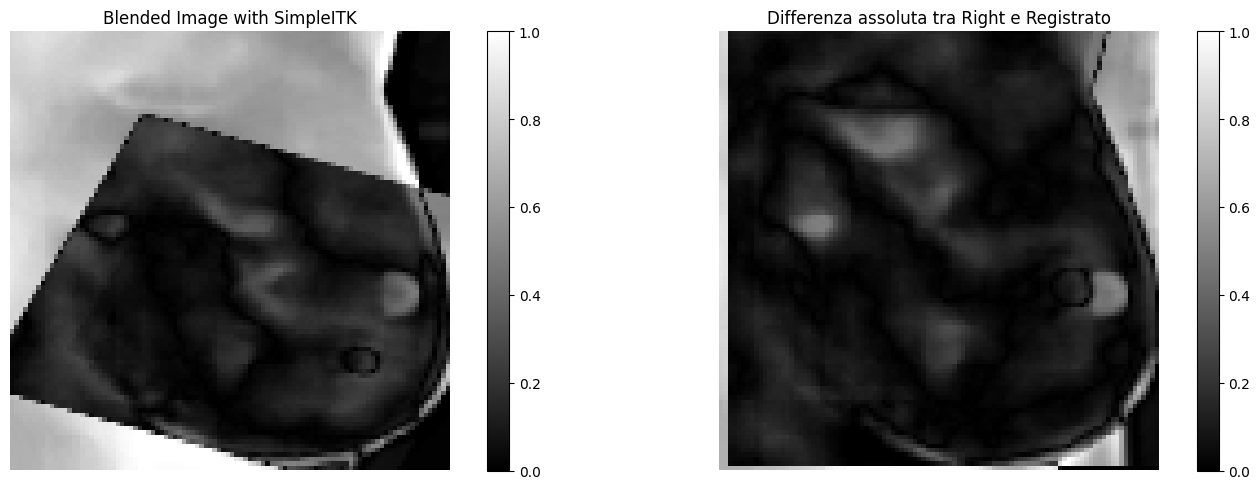

In [ ]:
diff1 = cv2.absdiff(right, im2_aligned)
diff2 = cv2.absdiff(right, registered)
diff1 = diff1.astype(np.float32)
diff1 = (diff1 - diff1.min()) / (diff1.max() - diff1.min())
diff2 = diff2.astype(np.float32)
diff2 = (diff2 - diff2.min()) / (diff2.max() - diff2.min())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(diff1, cmap="gray")
ax[0].set_title("Absolute Difference between Right and Registered (ECC)")
ax[0].axis('off')
ax[1].imshow(diff2, cmap="grey")
ax[1].set_title("Absolute Difference between Right and Registered (SimpleITK)")
ax[1].axis('off')

plt.colorbar(ax[0].imshow(diff1, cmap="gray"), ax=ax[0])
plt.colorbar(ax[1].imshow(diff2, cmap="gray"), ax=ax[1])

plt.tight_layout()
plt.show()